# 1. Library Import 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# 2. Load dataset

In [2]:
file_path = '../data/predictive_maintenance.csv'
train_df = pd.read_csv(file_path)

print("Dataset Predictive Maintenance Berhasil Dimuat!")
print(f"Dimensi Data: {train_df.shape[0]} Baris, {train_df.shape[1]} Kolom")

Dataset Predictive Maintenance Berhasil Dimuat!
Dimensi Data: 10000 Baris, 10 Kolom


# 3. Feature dan Label

In [3]:
# Memisahkan Fitur (X) dan Label/Target (y)
X = train_df.drop(columns=['UDI', 'Product ID', 'Target', 'Failure Type'])
y = train_df['Target']

print("Pemisahan Fitur dan Target Selesai.")
print(f"Kolom Fitur yang Digunakan: {X.columns.tolist()}")
print(f"Distribusi Target Asli:\n{y.value_counts()}")

Pemisahan Fitur dan Target Selesai.
Kolom Fitur yang Digunakan: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Distribusi Target Asli:
Target
0    9661
1     339
Name: count, dtype: int64


# 4. Split Dataset

In [4]:
# Membagi data menjadi 80% Training dan 20% Testing (Stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Split Data Selesai. Training: {X_train_raw.shape[0]} baris, Testing: {X_test_raw.shape[0]} baris.")

Split Data Selesai. Training: 8000 baris, Testing: 2000 baris.


# 5. Preprocessing


In [5]:
# Mengelompokkan kolom berdasarkan tipe datanya
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
categorical_cols = ['Type']

# Pipeline numerik: Mengisi NaN (jika ada) dengan median + Scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline kategorikal: Mengisi NaN dengan modus + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Menggabungkan seluruh rangkaian preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Eksekusi Transformasi Data
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print("Rangkaian Preprocessing Selesai Sempurna!")

Rangkaian Preprocessing Selesai Sempurna!


# 6. Handling Imbalance (SMOTE)

In [6]:
# Data Asli (Imbalance)
X_train_asli = X_train_processed
y_train_asli = y_train

# Data Balancing (SMOTE) karena data kerusakan mesin biasanya sangat timpang
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Dua Versi Data Siap Diuji:")
print(f"   - Data Asli (Imbalance) : {X_train_asli.shape[0]} baris")
print(f"   - Data SMOTE (Balanced) : {X_train_smote.shape[0]} baris")

Dua Versi Data Siap Diuji:
   - Data Asli (Imbalance) : 8000 baris
   - Data SMOTE (Balanced) : 15458 baris


# 7. Training dan Hyperparameter (HPO)

In [7]:
# Mencari nilai K terbaik ganjil dari 1 sampai 21 menggunakan GridSearchCV
param_grid = {'n_neighbors': list(range(1, 22, 2)), 'weights': ['uniform']}

print("Menjalankan HPO pada Data Asli")
grid_asli = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_asli.fit(X_train_asli, y_train_asli)
best_k_asli = grid_asli.best_params_['n_neighbors']

print("Menjalankan HPO pada Data Pasca SMOTE")
grid_smote = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_smote.fit(X_train_smote, y_train_smote)
best_k_smote = grid_smote.best_params_['n_neighbors']

print(f"\n[Hasil HPO Best K]: Data Asli K = {best_k_asli} | Data SMOTE K = {best_k_smote}")

Menjalankan HPO pada Data Asli
Menjalankan HPO pada Data Pasca SMOTE

[Hasil HPO Best K]: Data Asli K = 5 | Data SMOTE K = 1


# 8. Akurasi dan Threshold

In [8]:
# Latih model final menggunakan parameter terbaik masing-masing
knn_asli_final = KNeighborsClassifier(n_neighbors=best_k_asli, weights='uniform').fit(X_train_asli, y_train_asli)
knn_smote_final = KNeighborsClassifier(n_neighbors=best_k_smote, weights='uniform').fit(X_train_smote, y_train_smote)

# Prediksi ke data uji
y_pred_asli = knn_asli_final.predict(X_test_processed)
y_pred_smote = knn_smote_final.predict(X_test_processed)

acc_asli = accuracy_score(y_test, y_pred_asli)
acc_smote = accuracy_score(y_test, y_pred_smote)

print(f"Akurasi Akhir Data Asli  : {acc_asli * 100:.2f}%")
print(f"Akurasi Akhir Data SMOTE : {acc_smote * 100:.2f}%")

Akurasi Akhir Data Asli  : 97.40%
Akurasi Akhir Data SMOTE : 95.60%


# 9. Confusion Matrix

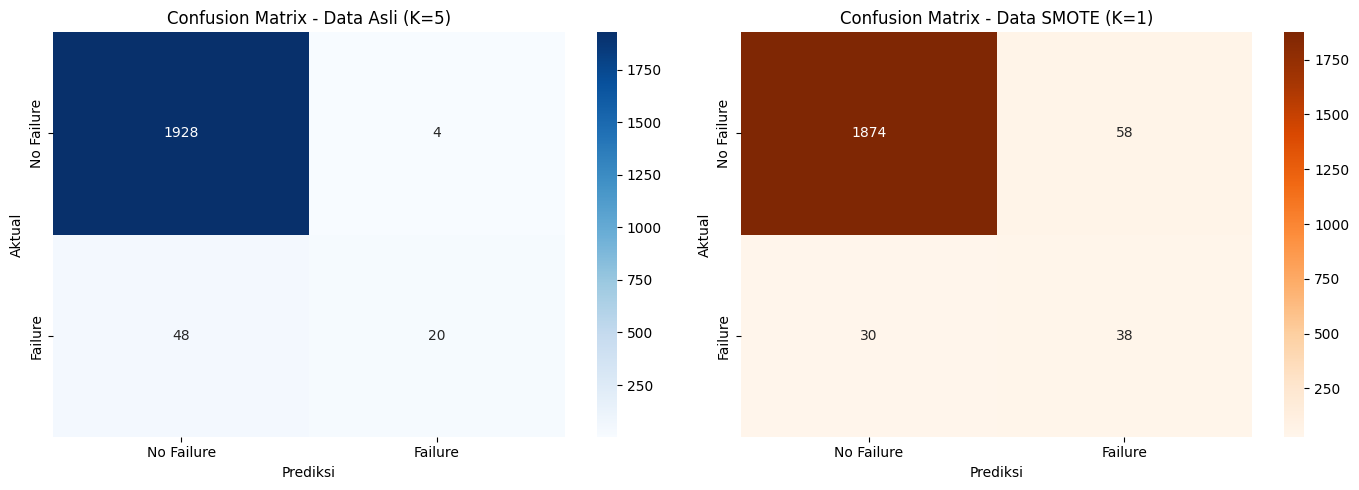

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Perhitungan & Plot Data Asli 
cm_asli = confusion_matrix(y_test, y_pred_asli)
sns.heatmap(cm_asli, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
ax[0].set_title(f'Confusion Matrix - Data Asli (K={best_k_asli})')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

# Mengambil nilai precision, recall, f1 untuk kelas Failure (posisi indeks 1)
prec_asli, rec_asli, f1_asli, _ = precision_recall_fscore_support(y_test, y_pred_asli, average='binary')

# 2. Perhitungan & Plot Data SMOTE 
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Oranges', ax=ax[1],
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
ax[1].set_title(f'Confusion Matrix - Data SMOTE (K={best_k_smote})')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

# Mengambil nilai precision, recall, f1 untuk kelas Failure (posisi indeks 1)
prec_smote, rec_smote, f1_smote, _ = precision_recall_fscore_support(y_test, y_pred_smote, average='binary')

plt.tight_layout()
plt.show()

# 10. Detail Perbandingan

In [10]:
import pandas as pd

# Membuat data perbandingan metrik secara berjejer
data_perbandingan = {
    'Metrik Evaluasi': ['Accuracy (Akurasi Global)', 'Precision (Kelas Failure)', 'Recall (Kelas Failure)', 'F1-Score (Kelas Failure)'],
    'Data Mentah (Imbalance)': [acc_asli, prec_asli, rec_asli, f1_asli],
    'Data Pasca SMOTE': [acc_smote, prec_smote, rec_smote, f1_smote]
}

# Mengubah menjadi DataFrame dan membulatkan nilainya menjadi desimal 4 angka di belakang koma
df_perbandingan = pd.DataFrame(data_perbandingan)


print("📊 TABEL DETAIL PERBANDINGAN PERFORMA MODEL (DATA ASLI VS SMOTE)")
print(df_perbandingan.to_string(index=False, formatters={
    'Data Mentah (Imbalance)': '{:,.4f}'.format,
    'Data Pasca SMOTE': '{:,.4f}'.format
}))
print("========================================================================")

# Logika penentuan keputusan otomatis untuk model_final
if acc_asli >= acc_smote:
    print(f"\n KESIMPULAN: Nilai Akurasi Data Asli ({acc_asli*100:.2f}%) lebih unggul.")
    print("   Keputusan: Menggunakan model 'knn_asli_final' untuk export sistem.")
    model_final = knn_asli_final
else:
    print(f"\n KESIMPULAN: Nilai Akurasi Data SMOTE ({acc_smote*100:.2f}%) lebih unggul.")
    print("Keputusan: Menggunakan model 'knn_smote_final' untuk export sistem.")
    model_final = knn_smote_final

📊 TABEL DETAIL PERBANDINGAN PERFORMA MODEL (DATA ASLI VS SMOTE)
          Metrik Evaluasi Data Mentah (Imbalance) Data Pasca SMOTE
Accuracy (Akurasi Global)                  0.9740           0.9560
Precision (Kelas Failure)                  0.8333           0.3958
   Recall (Kelas Failure)                  0.2941           0.5588
 F1-Score (Kelas Failure)                  0.4348           0.4634

 KESIMPULAN: Nilai Akurasi Data Asli (97.40%) lebih unggul.
   Keputusan: Menggunakan model 'knn_asli_final' untuk export sistem.


# 11. Simpan Model


In [13]:
# Amankan folder penyimpanan model
target_dir = '../models'
os.makedirs(target_dir, exist_ok=True)

# Amankan nama fitur asli
nama_fitur_final = X.columns.tolist()

# Simpan semua komponen ke folder models lokal
joblib.dump(model_final, os.path.join(target_dir, 'knn_model_maintenance.pkl'))
joblib.dump(preprocessor, os.path.join(target_dir, 'knn_preprocessor_maintenance.pkl'))
joblib.dump(nama_fitur_final, os.path.join(target_dir, 'knn_selected_features_maintenance.pkl'))

print("Seluruh file model .pkl sukses disimpan di folder 'models/'!")

Seluruh file model .pkl sukses disimpan di folder 'models/'!


# 12. Sanity Check


In [12]:
# Menguji kelayakan 5 sampel data pertama dari data pengujian menggunakan model final terpilih
sampel_uji = X_test_processed[:5]
hasil_prediksi = model_final.predict(sampel_uji)
probabilitas = model_final.predict_proba(sampel_uji)[:, 1] # Ambil probabilitas failure (kelas 1)

tabel_sanity = pd.DataFrame({
    'Data Aktual (True)'   : y_test.iloc[:5].values,
    'Prediksi Model k-NN'  : hasil_prediksi,
    'Probabilitas Failure' : probabilitas.round(3)
})

print("HASIL SANITY CHECK FINAL MODEL (PREDICTIVE MAINTENANCE)")
print(tabel_sanity)

HASIL SANITY CHECK FINAL MODEL (PREDICTIVE MAINTENANCE)
   Data Aktual (True)  Prediksi Model k-NN  Probabilitas Failure
0                   0                    0                   0.0
1                   0                    0                   0.0
2                   0                    0                   0.0
3                   0                    0                   0.0
4                   0                    0                   0.0
